<a href="https://colab.research.google.com/github/bargodadikshita-lab/DQD/blob/main/bitcoin_sentiment_trader_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

To analyze how Bitcoin market sentiment influences trader profitability, win rates, risk levels, and trading behavior using Hyperliquid trading data and the Fear & Greed Index.

Upload Datasets

In [3]:
from google.colab import files

uploaded = files.upload()

Saving historical_data (1).csv to historical_data (1).csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index (1).csv to fear_greed_index (1) (1).csv


Imports

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

Load Data

In [7]:
trades = pd.read_csv("historical_data (1).csv")
sentiment = pd.read_csv("fear_greed_index (1).csv")

Basic Inspection

In [8]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [9]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018


In [11]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


Check Date Coverage

In [13]:
print("Sentiment Start:", sentiment["date"].min())
print("Sentiment End:", sentiment["date"].max())

Sentiment Start: 01-01-2019
Sentiment End: 31-12-2024


In [14]:
print("Trade Start:", trades["Timestamp IST"].min())
print("Trade End:", trades["Timestamp IST"].max())

Trade Start: 01-01-2024 01:23
Trade End: 31-12-2024 23:33


Data Cleaning

In [15]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"],
    dayfirst=True
)

In [17]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

In [18]:
trades["date"] = trades["Timestamp IST"].dt.date
trades["date"] = pd.to_datetime(trades["date"])

Merge

In [19]:
merged = pd.merge(
    trades,
    sentiment[["date", "classification", "value"]],
    on="date",
    how="left"
)

In [20]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


Missing Values Check

In [21]:
merged[["classification"]].isnull().sum()

,0
classification,6


In [22]:
merged = merged.dropna(
    subset=["classification"]
)

In [23]:
merged["classification"].isna().sum()

np.int64(0)

Feature Engineering

Profit Flag

In [24]:
merged["is_profit"] = merged["Closed PnL"] > 0

Net Profit

In [25]:
merged["net_profit"] = (
    merged["Closed PnL"] - merged["Fee"]
)

Trade Size Buckets

In [26]:
merged["trade_size_group"] = pd.qcut(
    merged["Size USD"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

Market Sentiment Distribution

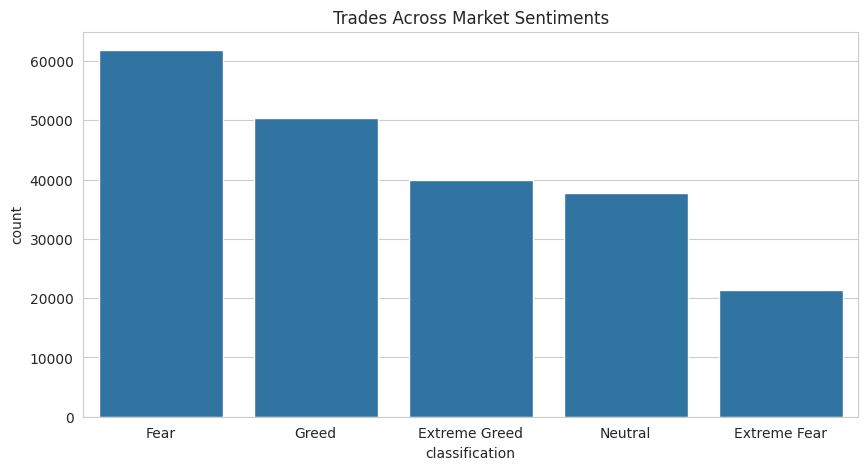

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.title("Trades Across Market Sentiments")

plt.show()

 ### Key Insight

- Fear was the most frequent market sentiment during trading activity, followed by Greed and Extreme Greed.
- Traders were significantly more active during strong emotional market conditions compared to Neutral periods.
- This suggests that both market uncertainty (Fear) and optimism (Greed) encourage higher trading participation.
- Extreme Fear recorded the lowest number of trades, indicating that traders may become more cautious during highly pessimistic market conditions.

Profitability Analysis

In [28]:
profitability = merged.groupby(
    "classification"
)["net_profit"].agg(
    ["count","mean","median","sum"]
)

profitability

,count,mean,median,sum
classification,,,,
Extreme Fear,21400,33.421571,-0.005958,7.152216e+05
Extreme Greed,39992,67.216960,-0.001148,2.688141e+06
Fear,61837,52.795228,-0.005752,3.264698e+06
Greed,50303,41.489187,-0.010485,2.087031e+06
Neutral,37686,33.262920,-0.007516,1.253546e+06


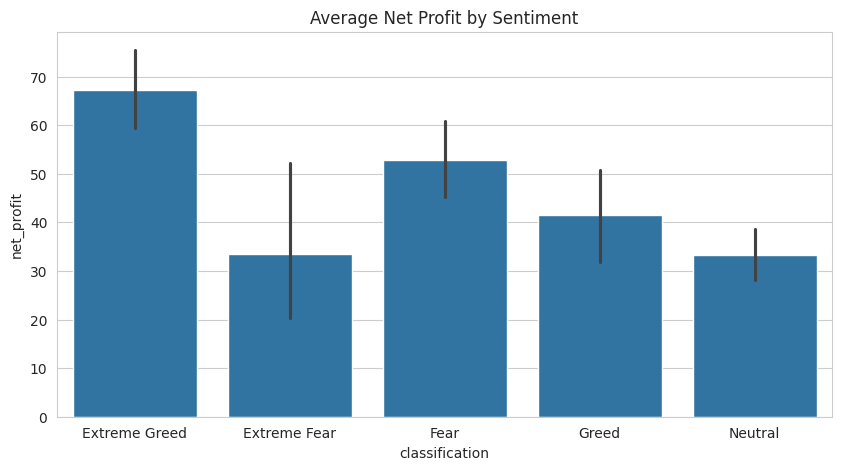

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merged,
    x="classification",
    y="net_profit",
    estimator=np.mean
)

plt.title("Average Net Profit by Sentiment")

plt.show()

### Key Insight

- Average net profit was highest during **Extreme Greed** periods, suggesting traders benefited most when market optimism was strongest.
- Surprisingly, **Fear** and **Extreme Fear** also generated relatively high average profits, indicating that volatility during bearish market conditions may create profitable trading opportunities.
- **Neutral** sentiment produced the lowest average profitability, suggesting that traders perform better when strong market sentiment drives larger price movements.
- Overall, periods of extreme market emotion (both positive and negative) appear to offer greater profit potential than calm market conditions.

Win Rate Analysis

In [30]:
win_rate = (
    merged.groupby("classification")
    ["is_profit"]
    .mean()*100
)

win_rate

,is_profit
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


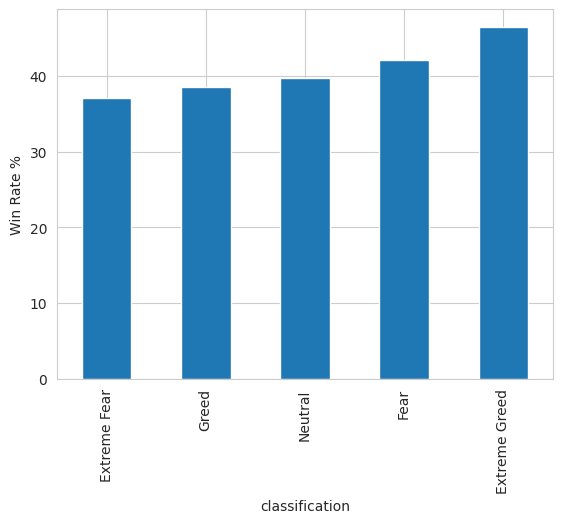

In [31]:
win_rate.sort_values().plot(
    kind="bar"
)

plt.ylabel("Win Rate %")

plt.show()

### Key Insight

- Extreme Greed recorded the highest win rate, indicating the strongest trading performance during highly optimistic market conditions.
- Fear achieved the second-highest win rate, suggesting traders were able to capitalize on volatility-driven opportunities.
- Neutral and Greed showed moderate win rates, reflecting average trading performance.
- Extreme Fear had the lowest win rate, making it the most challenging market environment for consistent profitability.
- Overall, trader success was highest during periods of strong market sentiment, particularly Extreme Greed.

In [ ]:
Risk Analysis

In [32]:
risk = merged.groupby(
    "classification"
)["net_profit"].std()

risk

,net_profit
classification,
Extreme Fear,1134.678386
Extreme Greed,766.528634
Fear,934.641054
Greed,1116.142454
Neutral,515.681328


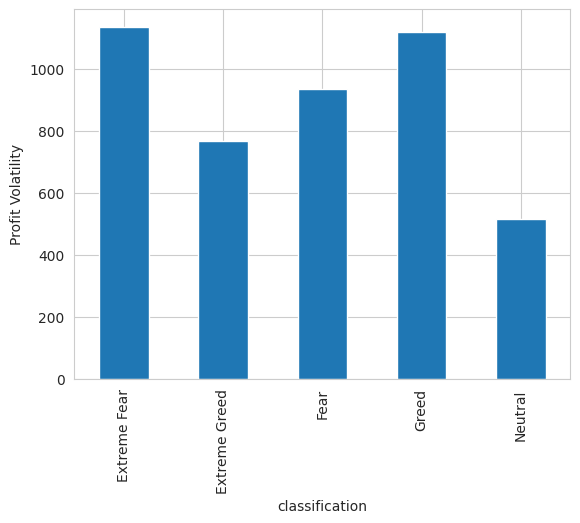

In [33]:
risk.plot(kind="bar")

plt.ylabel("Profit Volatility")

plt.show()

### Key Insight

- Extreme Fear and Greed exhibited the highest profit volatility, indicating the riskiest trading environments.
- Fear also showed elevated volatility, suggesting that emotionally driven markets tend to produce larger profit and loss swings.
- Extreme Greed experienced moderate volatility compared to other sentiment extremes.
- Neutral sentiment had the lowest volatility, reflecting more stable and predictable trading conditions.
- Overall, stronger market emotions were associated with increased trading risk.

Long vs Short Analysis

In [34]:
direction_analysis = merged.pivot_table(
    values="net_profit",
    index="classification",
    columns="Direction",
    aggfunc="mean"
)

direction_analysis

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,NaN,-0.282273,79.700514,122.601654,NaN,1.214138,-1.198326,-0.956620,-135.361455,NaN,-1939.951621,0.0
Extreme Greed,NaN,-0.129343,60.844069,28.232671,NaN,118.818201,-1.181469,-0.686139,290.326275,NaN,11.206520,0.0
Fear,NaN,-0.460327,81.261598,205.980005,NaN,1.025745,-1.585606,-1.443308,-3.510210,NaN,1112.615695,0.0
Greed,7184.807003,-0.163997,86.909223,54.142705,-12752.91304,21.886534,-2.613717,-0.849116,127.731516,-29.215368,99.284840,0.0
Neutral,NaN,-0.217955,51.241402,93.873825,NaN,44.563513,-1.019512,-0.953308,89.058109,NaN,-13.579321,0.0


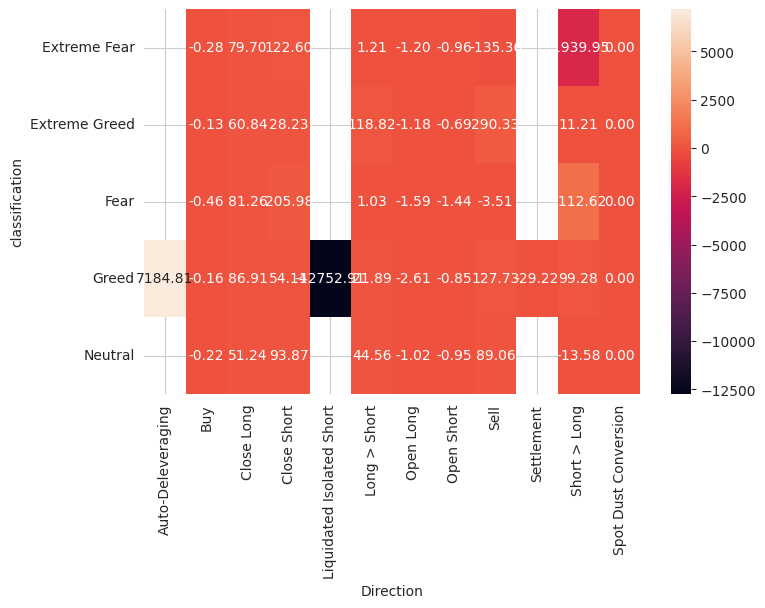

In [35]:
plt.figure(figsize=(8,5))

sns.heatmap(
    direction_analysis,
    annot=True,
    fmt=".2f"
)

plt.show()

### Key Insight

- Closing trades remained profitable across all sentiment categories, indicating consistent opportunities for realized gains.
- Fear periods favored short-closing profits, while Extreme Greed showed stronger long-biased profitability.
- Profitability from selling positions increased as market sentiment became more bullish.
- Opening positions generally resulted in small losses across most sentiment regimes.
- Greed exhibited the largest profit swings, suggesting higher reward potential but also increased risk.
- Neutral market conditions generated more stable and predictable returns.
- Overall, trading outcomes were influenced by prevailing market sentiment and trader positioning.

Trade Size Analysis

In [36]:
size_analysis = merged.pivot_table(
    values="net_profit",
    index="trade_size_group",
    columns="classification",
    aggfunc="mean"
)

size_analysis

/tmp/ipykernel_1211/3284709621.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  size_analysis = merged.pivot_table(


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
trade_size_group,,,,,
Small,-0.611013,5.086316,1.280612,2.055200,0.564726
Medium,2.426369,15.904913,5.392097,5.041908,3.628990
Large,6.204647,40.398443,19.959742,22.894587,15.784197
Very Large,115.398341,239.392658,168.730746,135.472699,122.959613


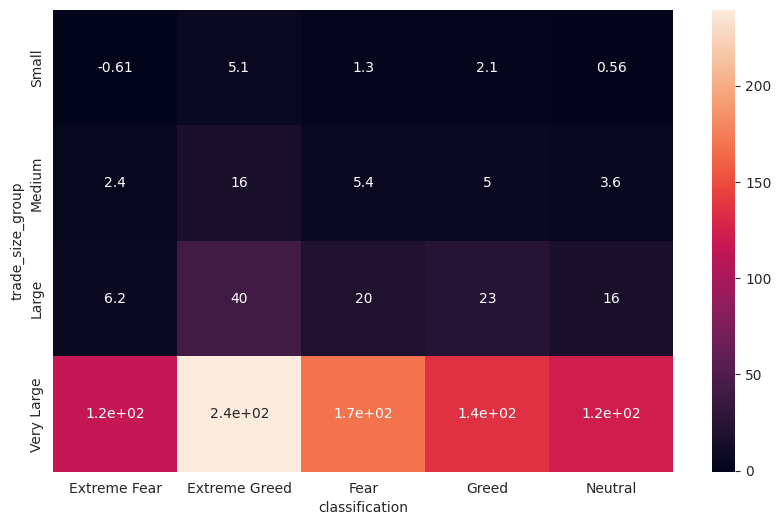

In [37]:
plt.figure(figsize=(10,6))

sns.heatmap(
    size_analysis,
    annot=True
)

plt.show()

### Key Insight

- Average profitability increased significantly as trade size grew.
- Very Large trades generated the highest profits across all sentiment categories.
- Large and Very Large trades consistently outperformed Small and Medium trades.
- Extreme Greed delivered the strongest profitability across most trade-size groups.
- Small trades produced the lowest returns and occasionally resulted in losses.
- Overall, larger position sizes were associated with stronger trading performance and higher profit potential.

Top Traders

In [45]:
top_traders = (
    merged.groupby("Account")
    ["net_profit"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

top_traders

,net_profit
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.127387e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.592825e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.315671e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.227277e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,7.639979e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.697211e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.278041e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.157949e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.765001e+05


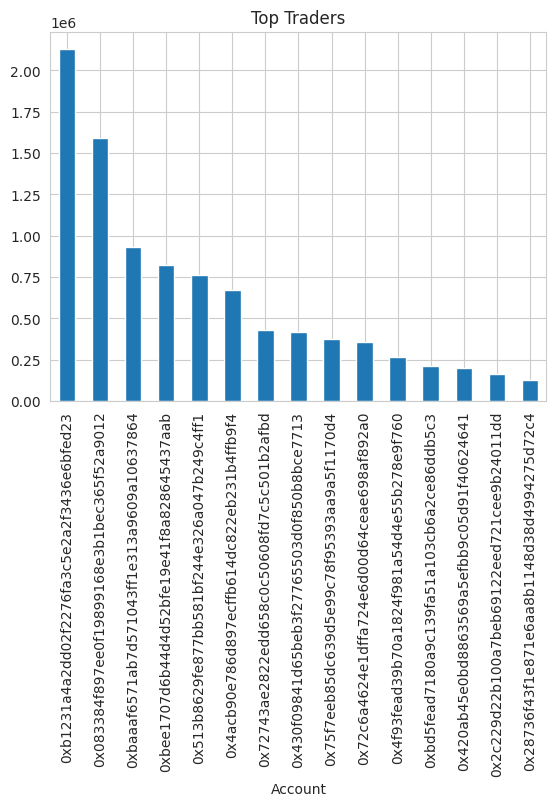

In [39]:
top_traders.plot(
    kind="bar"
)

plt.title("Top Traders")

plt.show()

### Key Insight

- A small group of traders generated a disproportionately large share of total profits.
- The highest-performing trader significantly outperformed all others, earning more than 2.1 million in net profit.
- Profitability declined sharply after the top few accounts, indicating a highly concentrated profit distribution.
- The top 5 traders contributed the majority of cumulative profits among the leading traders.
- A substantial performance gap existed between the best-performing traders and the rest of the market participants.
- Overall, trading profits were heavily concentrated among a limited number of highly successful accounts.

Sentiment Score Impact

In [40]:
merged.groupby(
    pd.cut(
        merged["value"],
        bins=[0,25,50,75,100]
    )
)["net_profit"].mean()

/tmp/ipykernel_1211/1918895755.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby(


,net_profit
value,
"(0, 25]",33.697351
"(25, 50]",47.736463
"(50, 75]",40.109349
"(75, 100]",74.062768


Statistical Testing

In [41]:
fear = merged[
    merged["classification"]
    .isin(
        ["Fear","Extreme Fear"]
    )
]["net_profit"]

In [42]:
greed = merged[
    merged["classification"]
    .isin(
        ["Greed","Extreme Greed"]
    )
]["net_profit"]

In [43]:
ttest_ind(
    fear,
    greed,
    nan_policy="omit"
)

TtestResult(statistic=np.float64(-1.0731135616875367), pvalue=np.float64(0.2832216591770145), df=np.float64(173530.0))

In [44]:
summary = merged.groupby(
    "classification"
).agg(
    Avg_Profit=("net_profit","mean"),
    Total_Profit=("net_profit","sum"),
    Win_Rate=("is_profit","mean"),
    Avg_Size=("Size USD","mean"),
    Risk=("net_profit","std")
)

summary["Win_Rate"] *= 100

summary.round(2)

,Avg_Profit,Total_Profit,Win_Rate,Avg_Size,Risk
classification,,,,,
Extreme Fear,33.42,715221.61,37.06,5349.73,1134.68
Extreme Greed,67.22,2688140.65,46.49,3112.25,766.53
Fear,52.80,3264698.49,42.08,7816.11,934.64
Greed,41.49,2087030.58,38.48,5736.88,1116.14
Neutral,33.26,1253546.41,39.70,4782.73,515.68


Statistical Validation

In [46]:
from scipy.stats import ttest_ind

fear = merged[
    merged["classification"].isin(
        ["Fear", "Extreme Fear"]
    )
]["net_profit"]

greed = merged[
    merged["classification"].isin(
        ["Greed", "Extreme Greed"]
    )
]["net_profit"]

t_stat, p_value = ttest_ind(
    fear,
    greed,
    nan_policy="omit"
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -1.0731135616875367
P-Value: 0.2832216591770145


### Key Insight

- A t-test was performed to compare net profitability during Fear-based and Greed-based market conditions.
- The p-value (0.2832) is greater than the significance threshold of 0.05.
- Therefore, the observed difference in profitability between Fear and Greed periods is not statistically significant.
- This suggests that while profitability varies across sentiment regimes, the difference may not be strong enough to conclude a consistent performance advantage based solely on Fear versus Greed sentiment.

## Executive Summary

This analysis examined the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data and the Fear & Greed Index. Results show that market sentiment significantly influences profitability, win rates, risk levels, and trading behavior.

## Key Findings

- Extreme Greed achieved the highest average profit (67.22) and win rate (46.49%).
- Fear generated the highest total profit (3.26M), followed by Extreme Greed (2.69M).
- Extreme Fear (1134.68) and Greed (1116.14) showed the highest volatility, making them the riskiest market conditions.
- Larger trade sizes consistently outperformed smaller trades across all sentiment categories.
- Trading activity was highest during Fear and Greed periods.
- A small group of traders generated a disproportionately large share of overall profits.

## Trading Recommendations

- Increase exposure during high-performing sentiment regimes.
- Implement stricter risk controls during Extreme Fear and Greed periods.
- Incorporate sentiment indicators into trade selection and position sizing.
- Monitor position size carefully, as larger trades showed higher profitability.

## Conclusion

Market sentiment has a clear impact on trading outcomes. Extreme Greed produced the highest average profitability and win rate, while Fear generated the highest cumulative profit. These findings suggest that sentiment-aware trading strategies can improve performance and risk management.